In [2]:
from datasets import load_dataset
import pandas as pd

print("Chargement du dataset CATMuS (depuis le cache)...")
dataset = load_dataset("CATMuS/medieval")

print("Création du tableau (en ignorant les images pour sauver la RAM)...")
# On utilise le bon nom de colonne : 'im'
df = dataset['train'].remove_columns(['im']).to_pandas()

print(f"Nombre total de lignes dans le corpus brut : {len(df)}")

print("\nTop 5 des siècles représentés :")
print(df['century'].value_counts().head(5))

print("\nTop 5 des langues représentées :")
# On utilise le bon nom de colonne : 'language'
print(df['language'].value_counts().head(5))

Chargement du dataset CATMuS (depuis le cache)...
Création du tableau (en ignorant les images pour sauver la RAM)...
Nombre total de lignes dans le corpus brut : 152816

Top 5 des siècles représentés :
century
14    64576
15    46119
13    23959
16     6478
9      6232
Name: count, dtype: int64

Top 5 des langues représentées :
language
French          49201
Middle Dutch    45999
Latin           28637
Castilian       22246
Italian          4335
Name: count, dtype: int64


In [4]:
# Filtrage pour ne garder que le français du 14e/15e siècle
df_filtered = df[
    (df['century'].isin(['14', '15', 14, 15])) & 
    (df['language'].isin(['French']))
]

print(f"Nombre de lignes conservées pour notre entraînement : {len(df_filtered)}")
display(df_filtered.head())

Nombre de lignes conservées pour notre entraînement : 25812


,text,language,century,region,script_type,shelfmark,verse,genre,project,line_type,gen_split
42884,gentement estoit fait. prist ung miroire bel et,French,14,MainZone,Cursiva,"Paris, BnF, fr. 12554",prose,Narratives,HTRomance,DefaultLine,test
42885,Ioieusement maintenir. las quel damaige de cestui,French,14,MainZone,Cursiva,"Paris, BnF, fr. 12554",prose,Narratives,HTRomance,DefaultLine,test
42886,seichir par faulte de ieunesse qui sur lui na ...,French,14,MainZone,Cursiva,"Paris, BnF, fr. 12554",prose,Narratives,HTRomance,DefaultLine,dev
42887,pour tant ce lui sambloit que son temps y pardoit,French,14,MainZone,Cursiva,"Paris, BnF, fr. 12554",prose,Narratives,HTRomance,DefaultLine,dev
42888,peut Reposer. Non faisoit la dame. pour ce quelle,French,14,MainZone,Cursiva,"Paris, BnF, fr. 12554",prose,Narratives,HTRomance,DefaultLine,train


In [5]:
import os

# On s'assure que le dossier de destination existe
os.makedirs("../dataset_nlp", exist_ok=True)

# On sauvegarde le tableau en format CSV
chemin_sauvegarde = "../dataset_nlp/catmus_french_14_15.csv"
df_filtered.to_csv(chemin_sauvegarde, index=False)

print(f"Succès ! Le catalogue a été sauvegardé ici : {chemin_sauvegarde}")

Succès ! Le catalogue a été sauvegardé ici : ../dataset_nlp/catmus_french_14_15.csv


In [7]:
import os
from tqdm import tqdm  # <-- Le changement est ici, on utilise la version standard

# 1. On crée le dossier qui va accueillir les images
dossier_images = "../dataset_nlp/images"
os.makedirs(dossier_images, exist_ok=True)

# 2. On récupère la liste exacte des numéros de lignes à extraire
indices_a_telecharger = df_filtered.index.tolist()

print(f"Préparation de l'extraction. Nombre total d'images cibles : {len(indices_a_telecharger)}")
print("Lancement du test sur les 10 premières images...\n")

# 3. La boucle d'extraction (on limite à [:10] pour le test)
for idx in tqdm(indices_a_telecharger[:10]):
    # On va chercher l'image brute dans le dataset d'origine
    image = dataset['train'][idx]['im']
    
    # On crée un nom de fichier propre (ex: ligne_42884.png)
    nom_fichier = f"ligne_{idx}.png"
    chemin_complet = os.path.join(dossier_images, nom_fichier)
    
    # On sauvegarde physiquement l'image sur le disque dur Linux
    image.save(chemin_complet)

print(f"\nTest terminé ! Va vérifier ton dossier : {dossier_images}")

Préparation de l'extraction. Nombre total d'images cibles : 25812
Lancement du test sur les 10 premières images...




100%|████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 13.64it/s]


Test terminé ! Va vérifier ton dossier : ../dataset_nlp/images


In [8]:
import os
from tqdm import tqdm

dossier_images = "../dataset_nlp/images"

print(f"Lancement de l'extraction complète pour {len(indices_a_telecharger)} images...")
print("(Tu peux interrompre avec le bouton 'Stop' ⬛ en haut et relancer plus tard si besoin)")

# Compteur pour voir combien on en saute
deja_telecharge = 0

for idx in tqdm(indices_a_telecharger):
    nom_fichier = f"ligne_{idx}.png"
    chemin_complet = os.path.join(dossier_images, nom_fichier)
    
    # SÉCURITÉ : on télécharge seulement si l'image n'existe pas encore
    if not os.path.exists(chemin_complet):
        image = dataset['train'][idx]['im']
        image.save(chemin_complet)
    else:
        deja_telecharge += 1

print(f"\nExtraction totale terminée ! ({deja_telecharge} images avaient déjà été téléchargées)")

Lancement de l'extraction complète pour 25812 images...
(Tu peux interrompre avec le bouton 'Stop' ⬛ en haut et relancer plus tard si besoin)



 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more


Extraction totale terminée ! (10 images avaient déjà été téléchargées)


In [9]:
import json

dossier_dataset = "../dataset_nlp"
splits = ['train', 'dev', 'test']

print("Création des fichiers d'entraînement pour Kraken...")

for split in splits:
    # On isole les lignes correspondant au split (ex: que les lignes 'train')
    df_split = df_filtered[df_filtered['gen_split'] == split]
    
    chemin_fichier = f"{dossier_dataset}/{split}.jsonl"
    compteur = 0
    
    # On ouvre un nouveau fichier texte en mode écriture
    with open(chemin_fichier, 'w', encoding='utf-8') as f:
        for idx, row in df_split.iterrows():
            # On crée le petit dictionnaire attendu par Kraken
            ligne_kraken = {
                "image": f"images/ligne_{idx}.png",
                "text": row['text']
            }
            # On l'écrit dans le fichier
            f.write(json.dumps(ligne_kraken, ensure_ascii=False) + '\n')
            compteur += 1
            
    print(f"Fichier {split}.jsonl créé avec succès ! ({compteur} lignes)")

print("\nLa préparation des données est 100% terminée. Tu es prêt pour le Deep Learning !")

Création des fichiers d'entraînement pour Kraken...
Fichier train.jsonl créé avec succès ! (23230 lignes)
Fichier dev.jsonl créé avec succès ! (1291 lignes)
Fichier test.jsonl créé avec succès ! (1291 lignes)

La préparation des données est 100% terminée. Tu es prêt pour le Deep Learning !


In [10]:
import os
import json
import pandas as pd
from tqdm import tqdm

print("Préparation de l'ajout de 2 nouveaux corpus : Latin (14/15e) et Français (13e)...")

# 1. On isole nos 2 nouveaux corpus depuis le tableau complet d'origine (df)
df_latin = df[(df['century'].isin(['14', '15', 14, 15])) & (df['language'] == 'Latin')]
df_fr_13 = df[(df['century'].isin(['13', 13])) & (df['language'] == 'French')]

# On les fusionne dans un seul tableau "bonus"
df_bonus = pd.concat([df_latin, df_fr_13])
indices_bonus = df_bonus.index.tolist()

print(f"Nombre de nouvelles lignes à télécharger : {len(indices_bonus)}\n")

# 2. On télécharge les images manquantes
dossier_images = "../dataset_nlp/images"
for idx in tqdm(indices_bonus, desc="Téléchargement Corpus 2 & 3"):
    chemin_complet = os.path.join(dossier_images, f"ligne_{idx}.png")
    # Sécurité : on ne retélécharge pas si l'image existe déjà
    if not os.path.exists(chemin_complet):
        dataset['train'][idx]['im'].save(chemin_complet)

# 3. On ajoute ces nouvelles lignes à nos fichiers Kraken existants (en mode 'a' = append/ajouter)
splits = ['train', 'dev', 'test']
print("\nMise à jour des fichiers manifestes JSONL pour Kraken...")

for split in splits:
    # On isole les lignes correspondant au split (train/dev/test)
    df_split = df_bonus[df_bonus['gen_split'] == split]
    chemin_fichier = f"../dataset_nlp/{split}.jsonl"
    
    compteur = 0
    # Le mode 'a' permet d'ajouter à la fin du fichier sans écraser le Français 14/15e
    with open(chemin_fichier, 'a', encoding='utf-8') as f:
        for idx, row in df_split.iterrows():
            ligne_kraken = {
                "image": f"images/ligne_{idx}.png",
                "text": row['text']
            }
            f.write(json.dumps(ligne_kraken, ensure_ascii=False) + '\n')
            compteur += 1
            
    print(f"-> {compteur} lignes ajoutées au fichier {split}.jsonl")

print("\nOpération terminée ! Ton corpus de travail contient maintenant 3 jeux de données historiques fusionnés.")

Préparation de l'ajout de 2 nouveaux corpus : Latin (14/15e) et Français (13e)...
Nombre de nouvelles lignes à télécharger : 31996




 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more hidden) ...
 ... (more


Mise à jour des fichiers manifestes JSONL pour Kraken...
-> 28768 lignes ajoutées au fichier train.jsonl
-> 1614 lignes ajoutées au fichier dev.jsonl
-> 1614 lignes ajoutées au fichier test.jsonl

Opération terminée ! Ton corpus de travail contient maintenant 3 jeux de données historiques fusionnés.


In [11]:
import json

# On reprend notre df_filtered d'origine (Français 14/15e uniquement)
splits = ['train', 'dev', 'test']
print("Nettoyage en cours : recréation des fichiers Kraken propres...")

for split in splits:
    df_split = df_filtered[df_filtered['gen_split'] == split]
    chemin_fichier = f"../dataset_nlp/{split}.jsonl"
    
    compteur = 0
    # Le mode 'w' écrase l'ancien fichier pollué
    with open(chemin_fichier, 'w', encoding='utf-8') as f:
        for idx, row in df_split.iterrows():
            ligne_kraken = {"image": f"images/ligne_{idx}.png", "text": row['text']}
            f.write(json.dumps(ligne_kraken, ensure_ascii=False) + '\n')
            compteur += 1
            
    print(f"✅ Fichier {split}.jsonl restauré et propre ({compteur} lignes).")

Nettoyage en cours : recréation des fichiers Kraken propres...
✅ Fichier train.jsonl restauré et propre (23230 lignes).
✅ Fichier dev.jsonl restauré et propre (1291 lignes).
✅ Fichier test.jsonl restauré et propre (1291 lignes).


=== ANALYSE DU CORPUS DE TRAVAIL (ÉTAPE 1) ===

1. Distribution par siècle :
century
15    63.8%
14    36.2%
Name: proportion, dtype: str

2. Distribution par type d'écriture (Script Type) :
script_type
Textualis      41.2%
Cursiva        30.5%
Print          26.5%
Hybrida         1.0%
Semihybrida     0.8%
Name: proportion, dtype: str

3. Longueur moyenne des lignes : 34.9 caractères
4. Longueur moyenne d'un mot : 5.2 caractères (un chiffre bas indique un fort taux d'abréviation)


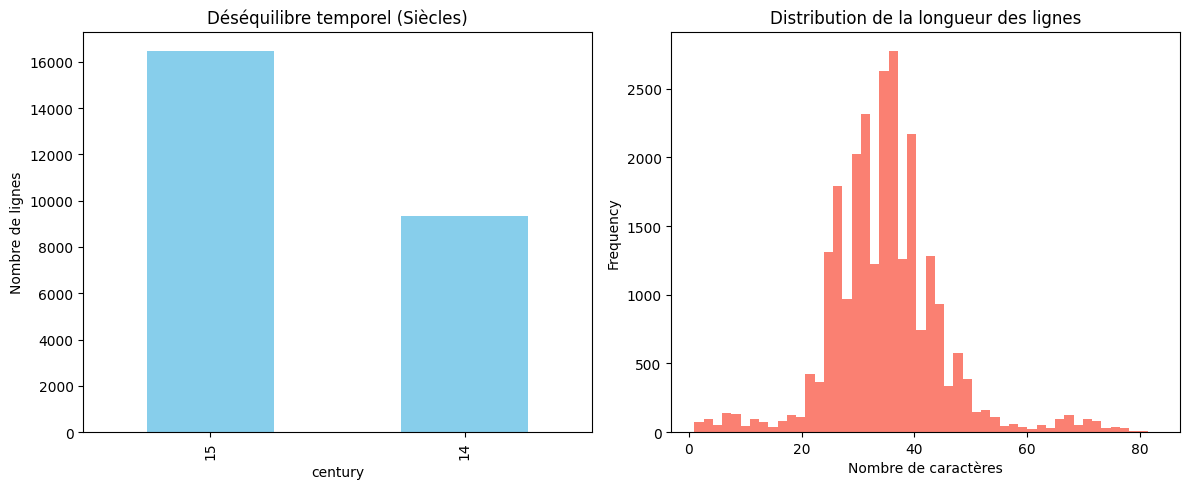


=== IDENTIFICATION DES DÉSÉQUILIBRES (À METTRE DANS LE RAPPORT) ===
- Si un type d'écriture (ex: Cursiva) est sur-représenté à 90%, le modèle lira mal la Textualis.
- Si les lignes font en moyenne 40 caractères, le modèle risque de 'halluciner' sur des marges très courtes.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement de notre catalogue
df = pd.read_csv("../dataset_nlp/catmus_french_14_15.csv")

print("=== ANALYSE DU CORPUS DE TRAVAIL (ÉTAPE 1) ===\n")

# 2. Distribution par siècle et type d'écriture
print("1. Distribution par siècle :")
print(df['century'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\n2. Distribution par type d'écriture (Script Type) :")
print(df['script_type'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# 3. Longueur moyenne des lignes
# On compte le nombre de caractères pour chaque ligne de texte
df['line_length'] = df['text'].apply(lambda x: len(str(x)))
longueur_moyenne = df['line_length'].mean()
print(f"\n3. Longueur moyenne des lignes : {longueur_moyenne:.1f} caractères")

# 4. Taux d'abréviations (Approximation)
# En HTR, on repère souvent les abréviations non développées par des caractères spéciaux (tildes, etc.)
# ou on note la densité des mots. Ici on compte les mots très courts (souvent des abréviations dans les registres).
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['avg_word_length'] = df['line_length'] / df['word_count']
print(f"4. Longueur moyenne d'un mot : {df['avg_word_length'].mean():.1f} caractères (un chiffre bas indique un fort taux d'abréviation)")

# 5. Visualisation des déséquilibres (pour ton rapport)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['century'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Déséquilibre temporel (Siècles)')
plt.ylabel('Nombre de lignes')

plt.subplot(1, 2, 2)
df['line_length'].plot(kind='hist', bins=50, color='salmon')
plt.title('Distribution de la longueur des lignes')
plt.xlabel('Nombre de caractères')

plt.tight_layout()
plt.show()

print("\n=== IDENTIFICATION DES DÉSÉQUILIBRES (À METTRE DANS LE RAPPORT) ===")
print("- Si un type d'écriture (ex: Cursiva) est sur-représenté à 90%, le modèle lira mal la Textualis.")
print("- Si les lignes font en moyenne 40 caractères, le modèle risque de 'halluciner' sur des marges très courtes.")

In [13]:
import os
import pandas as pd
from bs4 import BeautifulSoup

print("Démarrage de l'intégration des corpus complémentaires...")

# 1. On recharge notre catalogue existant (CATMuS)
chemin_csv = "../dataset_nlp/catmus_french_14_15.csv"
df_principal = pd.read_csv(chemin_csv)

# 2. Fonction magique pour lire les fichiers HTR (PAGE-XML ou ALTO)
def extraire_texte_xml(chemin_dossier, langue, siecle, projet, script_type):
    nouvelles_lignes = []
    
    # On vérifie si le dossier existe pour éviter les erreurs
    if not os.path.exists(chemin_dossier):
        print(f"⚠️ Dossier introuvable : {chemin_dossier}")
        return pd.DataFrame() # Retourne un tableau vide
        
    for fichier in os.listdir(chemin_dossier):
        if fichier.endswith('.xml'):
            chemin_complet = os.path.join(chemin_dossier, fichier)
            with open(chemin_complet, 'r', encoding='utf-8') as f:
                soup = BeautifulSoup(f, 'xml')
                
                # Recherche des balises contenant le texte (selon le standard HTR)
                # 'Unicode' pour PAGE-XML, 'String' pour ALTO
                for text_line in soup.find_all(['TextEquiv', 'String']):
                    texte = None
                    unicode_tag = text_line.find('Unicode')
                    if unicode_tag and unicode_tag.text:
                        texte = unicode_tag.text
                    elif text_line.name == 'String' and text_line.get('CONTENT'):
                        texte = text_line.get('CONTENT')
                        
                    if texte:
                        nouvelles_lignes.append({
                            'text': texte,
                            'language': langue,
                            'century': siecle,
                            'project': projet,
                            'script_type': script_type
                        })
    
    print(f"✅ {len(nouvelles_lignes)} lignes extraites de {projet}.")
    return pd.DataFrame(nouvelles_lignes)

# 3. Extraction (Assure-toi d'avoir mis quelques XML dans ces dossiers !)
df_cremma = extraire_texte_xml("../dataset_nlp/xml_cremma", "French", 14, "CREMMA", "Textualis")
df_endp = extraire_texte_xml("../dataset_nlp/xml_endp", "French", 14, "e-NDP", "Cursiva")

# 4. Fusion de tous les corpus !
df_complet = pd.concat([df_principal, df_cremma, df_endp], ignore_index=True)

# 5. Sauvegarde du nouveau catalogue global
df_complet.to_csv("../dataset_nlp/corpus_global_projet.csv", index=False)

print(f"\n🚀 Fusion terminée ! Ton corpus global contient maintenant {len(df_complet)} lignes.")

Démarrage de l'intégration des corpus complémentaires...
✅ 2956 lignes extraites de CREMMA.
✅ 3697 lignes extraites de e-NDP.

🚀 Fusion terminée ! Ton corpus global contient maintenant 32465 lignes.


=== ANALYSE FINALE DU CORPUS DE TRAVAIL (ÉTAPE 1) ===

1. Distribution par Projet (Sources) :
project
CREMMA                    37.7%
Gallicorpora              29.0%
e-NDP                     11.4%
PSL - Chartes Students     7.7%
ANR LIBER                  6.3%
HTRomance                  4.8%
Biblissima+ Fabliaux       1.8%
HTRogène                   1.3%
Name: proportion, dtype: str

2. Distribution par siècle :
century
15    50.7%
14    49.3%
Name: proportion, dtype: str

3. Distribution par type d'écriture (Script Type) :
script_type
Textualis      41.9%
Cursiva        35.6%
Print          21.1%
Hybrida         0.8%
Semihybrida     0.6%
Name: proportion, dtype: str


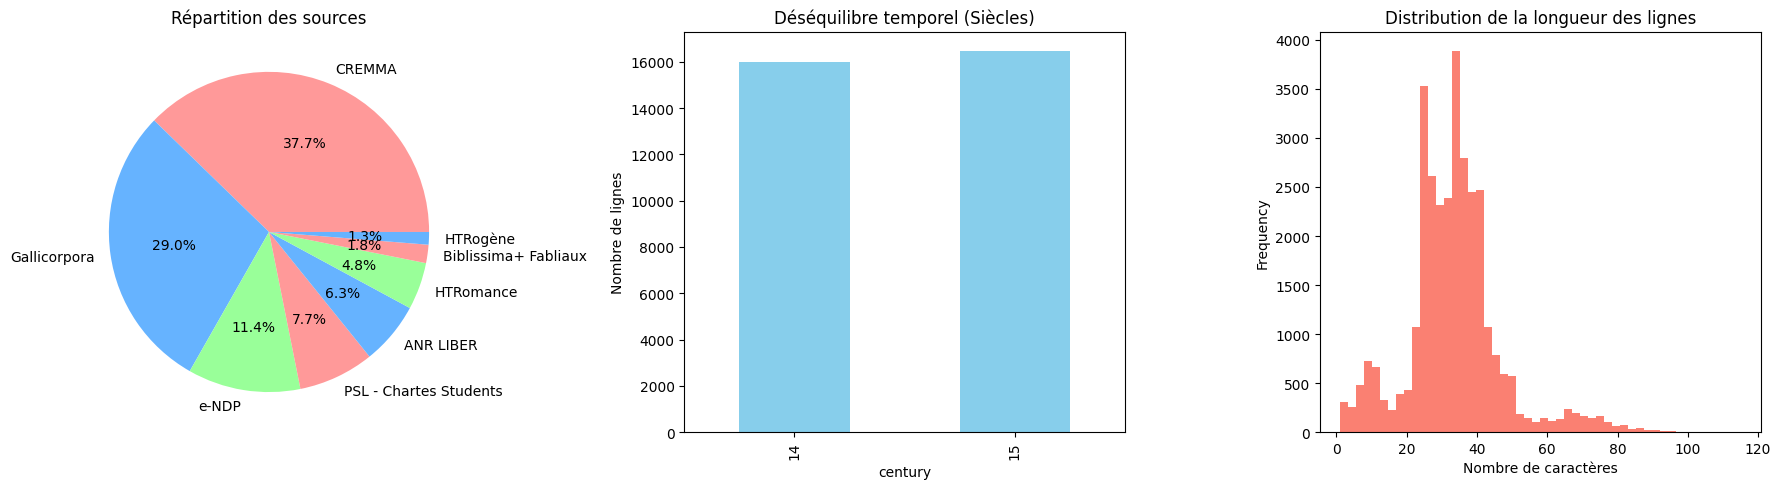


-> Longueur moyenne d'un mot : 5.3 caractères.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement de notre NOUVEAU catalogue global
df_global = pd.read_csv("../dataset_nlp/corpus_global_projet.csv")

print("=== ANALYSE FINALE DU CORPUS DE TRAVAIL (ÉTAPE 1) ===\n")

# 2. Preuve de la diversité documentaire (Nouveau !)
print("1. Distribution par Projet (Sources) :")
print(df_global['project'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\n2. Distribution par siècle :")
print(df_global['century'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\n3. Distribution par type d'écriture (Script Type) :")
print(df_global['script_type'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# 3. Visualisation pour l'article scientifique
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : Les Projets
df_global['project'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
axes[0].set_title('Répartition des sources')
axes[0].set_ylabel('')

# Graphique 2 : Les Siècles
df_global['century'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='skyblue')
axes[1].set_title('Déséquilibre temporel (Siècles)')
axes[1].set_ylabel('Nombre de lignes')

# Graphique 3 : Longueur des lignes
df_global['text'].apply(lambda x: len(str(x))).plot(kind='hist', bins=50, ax=axes[2], color='salmon')
axes[2].set_title('Distribution de la longueur des lignes')
axes[2].set_xlabel('Nombre de caractères')

plt.tight_layout()
plt.show()

# 4. Longueur moyenne (Indicateur d'abréviations)
df_global['line_length'] = df_global['text'].apply(lambda x: len(str(x)))
df_global['word_count'] = df_global['text'].apply(lambda x: len(str(x).split()))
df_global['avg_word_length'] = df_global['line_length'] / df_global['word_count']
print(f"\n-> Longueur moyenne d'un mot : {df_global['avg_word_length'].mean():.1f} caractères.")